# Methoden en Technieken -- Blok 1b

## Datapunt Opdracht
In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld
machine learning, deep learning**, kennisrepresentatie, computer vision en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model** volgens een iteratief en systematisch
proces.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
**explainability**, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)


In [75]:
import os
import torch

os.environ["KERAS_BACKEND"] = "torch"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import keras
import numpy as np
import matplotlib.pyplot as plt

## Data

In deze opdracht werken we met gesimuleerde data, deze wordt hier aangemaakt. We gaan hier wel van uit dat dit de volledige data is, het is niet toegestaan extra trekkingen te doen.

In [76]:
# Verband tussen x en y
def f(x):
    return (+ 1.5*np.tanh(20*x - 6)  
            - 2.0*np.tanh(10*x - 4)
            + 1.5*np.tanh( 8*x - 4)
            - 1.0*np.tanh(15*x - 12))


In [77]:
# Trek data
np.random.seed(42)# Random state 2 zorgt voor een bijna perfecte fit door puur geluk
xdat = np.random.uniform(0,1, size=1000).reshape(-1,1)
ydat = f(xdat) + np.random.normal(scale = 0.2, size = 1000).reshape(-1,1)

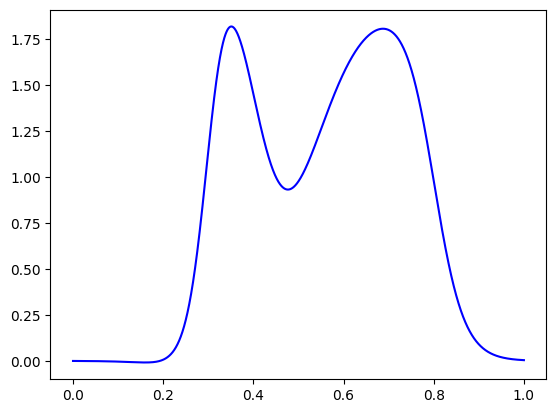

In [78]:
# Plot echt verband
xplot = np.linspace(0,1,10001)
yplot = f(xplot)
plt.plot(xplot, yplot, 'b-')
plt.show()

In deze opdracht is het de bedoeling om middels een neuraal netwerk de data $(xdat,ydat)$ die hierboven werdt gegeven te benaderen. Het uiteindelijke model behoort,
* de data / de functie $f$ zo goed mogelijk te benaderen, en
* zo simpel mogelijk te zijn (interpreteerbaarheid van model).

Tip: Lees eerst alle deelvragen goed door voordat je begint met beantwoorden.

### Split data right away

De data wordt gesplitst volgens de **standaard 70/15/15 verdeling** met behulp van `train_test_split` en `random_state=42` voor reproduceerbaarheid. Deze verdeling is de meest gangbare aanpak in de machine learning praktijk voor datasets van ongeveer 1000 samples.

**Waarom 70/15/15:**
- **70% training data**: Voldoende samples voor stabiel leren van de complexe functie
- **15% validation data**: Voldoende voor betrouwbare hyperparameter tuning en early stopping
- **15% test data**: Onafhankelijke evaluatie van model performance
- **Standaard verhouding**: Wordt breed geaccepteerd in de literatuur voor datasets van deze grootte

**Voordelen van deze aanpak:**
- Meer training data dan alternatieve splits zoals 60/20/20
- Gelijke validatie/test sets voor consistente evaluatie  
- Directe implementatie zonder geneste splits

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    xdat, ydat, 
    test_size=0.30,  # 30% for validation + test
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50,
    random_state=42,
    shuffle=True
)

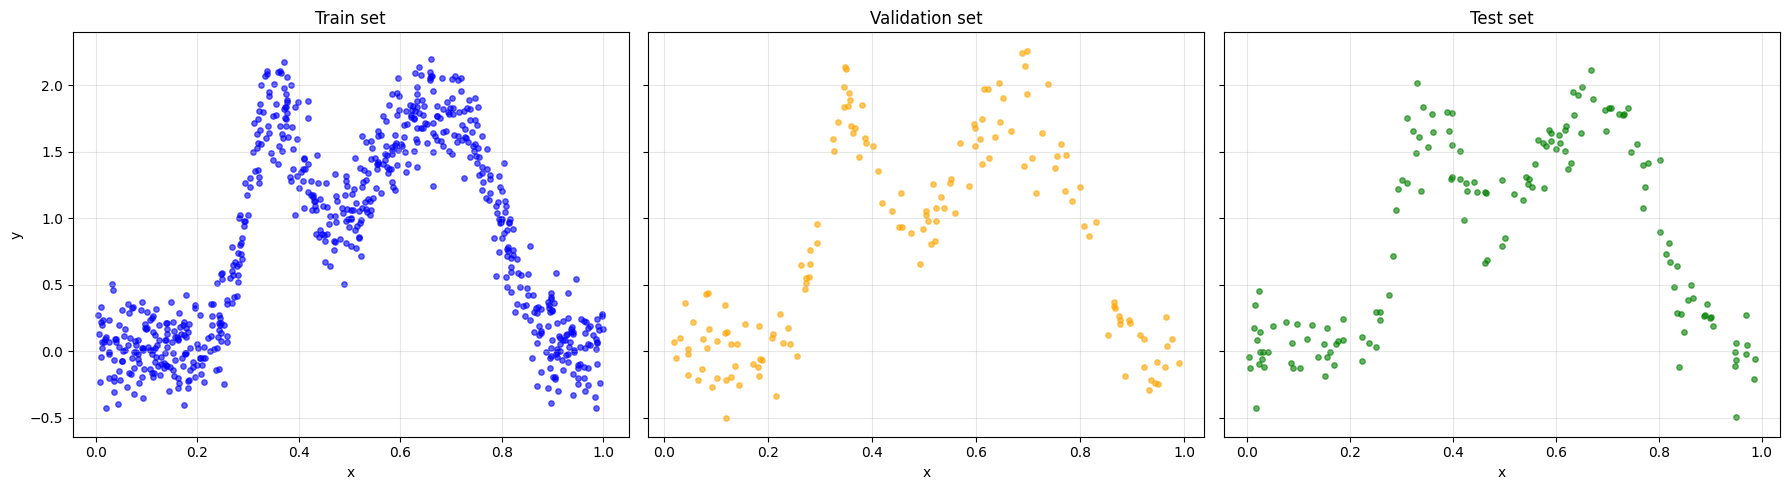

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Training set
axes[0].scatter(X_train, y_train, color='blue', alpha=0.6, s=15)
axes[0].set_title('Train set')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(X_val, y_val, color='orange', alpha=0.6, s=15)
axes[1].set_title('Validation set')
axes[1].set_xlabel('x')
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(X_test, y_test, color='green', alpha=0.6, s=15)
axes[2].set_title('Test set')
axes[2].set_xlabel('x')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Data verkenning

De dataset bestaat uit 1000 samples synthetische data met één input feature (x) en één target waarde (y). 

**Input data (x):** Uniform verdeeld tussen 0 en 1 (is al genormaliseerd)
**Target functie f(x):** Combinatie van 4 tanh-functies met verschillende parameters
**Ruis:** Gaussische ruis met σ=0.2 toegevoegd aan de echte functie

<br>

### Eigenschappen van de target functie

De functie `f(x) = 1.5*tanh(20x-6) - 2.0*tanh(10x-4) + 1.5*tanh(8x-4) - 1.0*tanh(15x-12)` heeft:
- **4 tanh-termen** die elk lokale krommingen creëren
- **Geen bias term** wat betekent dat ons model ook geen output bias nodig heeft
- **Complexe niet-lineaire vorm** die meerdere neuronen vereist om goed te modelleren

<br>

### Voor- en nadelen

**Voordelen:**
- Exacte functie bekend: perfecte evaluatie mogelijk
- Goed intrepreteerbaar omdat de data syntethisch en makkelijk te begrijpen is
- Schone data zonder missing values
- Er is al duidelijk dat bij een MAE lager dan 0.16 je overfit op de noise.

**Nadelen:**
- Kunstmatig: beperkte generaliseerbaarheid naar echte problemen
- Simpel probleem dus overfitting is mogelijk met te veel complexiteit voor het probleem


Ruis in training data:
  Gemiddelde ruis: 0.0241
  Standaarddeviatie ruis: 0.2009


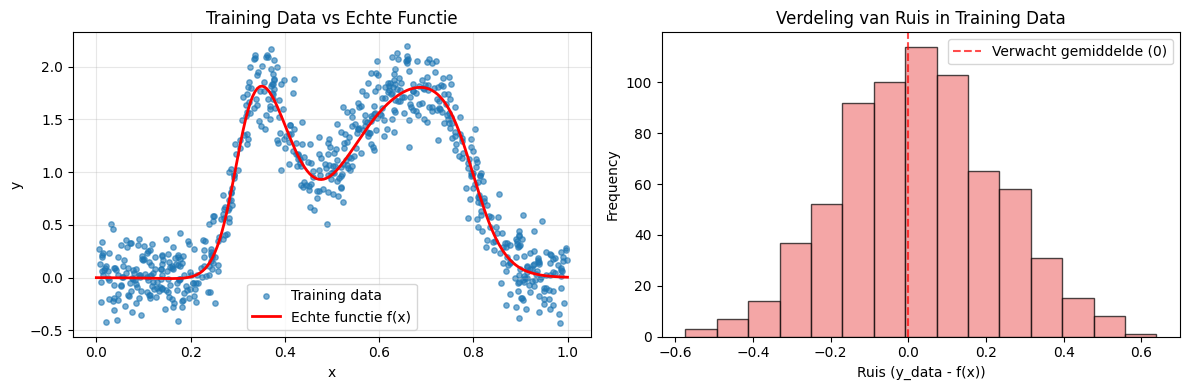

In [81]:
# Schatting van de ruis in training data
y_train_clean = f(X_train)  # Echte waarden zonder ruis
noise_train = y_train - y_train_clean
print(f"\nRuis in training data:")
print(f"  Gemiddelde ruis: {noise_train.mean():.4f}")
print(f"  Standaarddeviatie ruis: {noise_train.std():.4f}")

# Simpele visualisatie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training data scatter plot
ax1.scatter(X_train, y_train, alpha=0.6, s=15, label='Training data')
x_smooth = np.linspace(0, 1, 200)
ax1.plot(x_smooth, f(x_smooth), 'r-', linewidth=2, label='Echte functie f(x)')
ax1.set_title('Training Data vs Echte Functie')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Ruis verdeling
ax2.hist(noise_train.flatten(), bins=15, alpha=0.7, edgecolor='black', color='lightcoral')
ax2.set_title('Verdeling van Ruis in Training Data')
ax2.set_xlabel('Ruis (y_data - f(x))')
ax2.set_ylabel('Frequency')
ax2.axvline(0, color='red', linestyle='--', alpha=0.7, label='Verwacht gemiddelde (0)')
ax2.legend()

plt.tight_layout()
plt.show()

### Functionele en Technische requirements

- De functie $f$ zo goed mogelijk te benaderen door een goede score op de gekoze performance metric, in het geval van MAE dus rond de 0.16 want de rest is dan noise.
- Een nul model (baseline) maken om tegen te vergelijken.
- Beter performen van een simpel dummy model.
- Een performance metric die goed intrepreteerbaar is, dus mensenlijk begrijpbaar en duidelijk te vergelijken.
- Een zo simpel mogelijk model, door de laagst mogelijke hoeveelheid layers en neuronen.
- Het model voornamelijk tweaken door het aanpassen van hyperparameters, en niet door de architectuur aan te passen.
- SImpele goed intrepreteerbare helper functions zoals callbacks gebruiken voor data preprocessing en visualisatie.
- Duidelijke iteraties maken die het process goed inzichtelijk maken.
- De weights van het model opslaan zodat ze later bekeken kunnen worden en vergeleken.
- Zo min mogelijk bewerkingen aan de data zelf, alleen standaardisatie en reshaping zodat het intrepeteerbaar blijft aan het einde.

## Deel 1

Bestudeer de definitie van $f$ en de grafiek van deze functie.

Hoe zou een zo simpel mogelijk neuraal netwerk voor dit probleem er uit zou zien. Bijvoorbeeld: hoeveel nodes/neuronen zou het moeten hebben? Hoeveel gewichten? Welke activatiefunctie(s)? Wees zo specifiek mogelijk.

> Jouw antwoord hier

### Keuze van het aantal lagen

Op pagina 158 van het boek [*Introduction to Neural Networks for Java, Second Edition*](https://d1wqtxts1xzle7.cloudfront.net/62266271/Deep_Learning20200303-80130-1s42zvt.pdf?1738394282=&response-content-disposition=inline%3B+filename%3DDeep_Learning.pdf&Expires=1760352999&Signature=ASZMxP-rd7tkPYZ9zDstgcVsdpSJybNhQcBjTzaV5kdlxv~HUvC8Fe3ilLqhzMWbGSfXdTGE4Zagv2rkIXhIDGjam2uBCIx-sLfwcSuoXCGPWTo3bnslV7nQEv6MK6DaVxOVB7iQGweIHW9A8FMmoE8ZQoJ0ibs6EZ9ufJEpPm8m-NC8roGD~t5wWvNTbcfa79Uyt-bMsBPcUv60V8~gRmcVdQAY-ArCHkddeaCtHglQwT3GEr7TTjG5NYcJ5ccT7krKQVyI56neM6jf~bsUl4eRafDl3jwApErVOqTieB53nefClaAcAp1t0rjWy0yk~fzl5VvHmpDl08sPHbhXuw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)  
wordt beschreven dat een neuraal netwerk met één verborgen laag in staat is om elke continue functie te benaderen wat ook klopt volgens de universal approximation thereum.

Een vergelijkbare uitleg wordt gegeven in [*Deep Learning*](https://d1wqtxts1xzle7.cloudfront.net/62266271/Deep_Learning20200303-80130-1s42zvt.pdf?1738394282=&response-content-disposition=inline%3B+filename%3DDeep_Learning.pdf&Expires=1760352999&Signature=ASZMxP-rd7tkPYZ9zDstgcVsdpSJybNhQcBjTzaV5kdlxv~HUvC8Fe3ilLqhzMWbGSfXdTGE4Zagv2rkIXhIDGjam2uBCIx-sLfwcSuoXCGPWTo3bnslV7nQEv6MK6DaVxOVB7iQGweIHW9A8FMmoE8ZQoJ0ibs6EZ9ufJEpPm8m-NC8roGD~t5wWvNTbcfa79Uyt-bMsBPcUv60V8~gRmcVdQAY-ArCHkddeaCtHglQwT3GEr7TTjG5NYcJ5ccT7krKQVyI56neM6jf~bsUl4eRafDl3jwApErVOqTieB53nefClaAcAp1t0rjWy0yk~fzl5VvHmpDl08sPHbhXuw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)  
van Goodfellow, Bengio en Courville (p. 205, sectie 6.6 *Universal Approximation Properties and Depth*). Daarin wordt benadrukt dat één verborgen laag voldoende is om een brede klasse van continue functies te benaderen, mits er gebruik wordt gemaakt van een “squashing” activatiefunctie zoals sigmoid of tanh.

### Keuze van het aantal neuronen

Voor de bepaling van het aantal neuronen in de verborgen laag is gekeken naar hoe neuronen bijdragen aan de vorm van de te benaderen functie.  
In [*Neural Networks and Deep Learning*](http://neuralnetworksanddeeplearning.com/chap4.html#five_bumps) wordt uitgelegd dat elk extra neuron een extra “bump” (lokale kromming) in de functie mogelijk maakt. Daar wordt concreet getoond dat een netwerk met vijf neuronen de functie tot vijf keer op en neer kan laten gaan.  

Wiskundig kan dit principe worden uitgedrukt als $2n + 1$, waarbij $n$ het aantal neuronen in de verborgen laag is.  
Aangezien de doel­functie in dit geval drie stijgingen en twee dalingen vertoont, zijn minimaal vier neuronen nodig om deze correct te kunnen modelleren.  
Een netwerk met drie neuronen zou onvoldoende capaciteit hebben om deze variaties te reproduceren. Eén verborgen laag is hiervoor voldoende. En het gebruik van een squashing function zoals sigmoid of tanh wordt nog een keer aangehaald.

### Keuze van de activatiefunctie

Zoals beschreven in [*A Survey on Activation Functions and their Relation with Xavier and He Normal Initialization*](https://arxiv.org/pdf/2004.06632)  
(sectie 2.3.2, p. 8) is de **tanh-functie** een uitbreiding op de sigmoid-functie.  
Het belangrijkste voordeel van tanh is dat de output rond nul gecentreerd is, wat de backpropagation vergemakkelijkt en voorkomt dat de activatie te snel verzadigt.  

In de conclusie van dezelfde publicatie (p. 15) wordt bovendien vermeld dat de tanh-functie vaak de voorkeur heeft bij relatief ondiepe netwerken.  
Gecombineerd met de eerdere overwegingen (één verborgen laag met een squashing-activatie) is tanh daarom een logische en goed onderbouwde keuze voor dit model.

### Keuze van de weight-initialisatie

Wanneer de gewichten allemaal met dezelfde waarde (zoals 0 of 1) worden geïnitialiseerd, leren de neuronen identieke patronen dit staat bekend als het *symmetry problem*  
(zie [*Why Initialize a Neural Network with Random Weights?*](https://machinelearningmastery.com/why-initialize-a-neural-network-with-random-weights/), sectie *Why Not Set Weights to Zero?*).  
Daarom moeten de gewichten willekeurige startwaarden krijgen.

De waarden mogen echter niet te groot of te klein zijn.  
Zoals uitgelegd in [*Understanding and Study of Weight Initialization in Artificial Neural Networks with Back Propagation Algorithm*](http://it-in-industry.org/index.php/itii/article/view/290/253) (p. 5, net boven sectie 4 *Results*),  
kunnen te kleine waarden leiden tot het verdwijnen van signalen (*vanishing gradients*), terwijl te grote waarden juist explosieve gradiënten veroorzaken (*exploding gradients*).

In de abstract van [*Understanding the Difficulty of Training Deep Feedforward Neural Networks*](http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)  
wordt beschreven dat willekeurige initialisatie bij diepe netwerken vaak ongeschikt is omdat activaties daardoor te sterk krimpen of groeien vooral bij activatiefuncties zoals tanh.  

Daarom wordt in de literatuur vaak de **Xavier-initialisatie** aanbevolen.  
Deze methode is specifiek ontworpen voor activatiefuncties zoals sigmoid en tanh, en zorgt ervoor dat de variantie van activaties en gradiënten in balans blijft.  
Dit wordt ook helder uitgelegd in [*Xavier Initialization – GeeksforGeeks*](https://www.geeksforgeeks.org/deep-learning/xavier-initialization/), onder de sectie *Understanding Xavier Initialization*.

### Samengevat

Op basis van bovenstaande overwegingen is gekozen voor een **neuraal netwerk met één verborgen laag** en **vier neuronen**.  
De activatiefunctie in deze laag is **tanh**, omdat deze goed aansluit bij ondiepe netwerken en helpt om stabiele gradiënten te behouden.  
De gewichten worden geïnitialiseerd met **Xavier-initialisatie**, zodat de variatie van activaties en gradiënten in balans blijft en het leerproces efficiënt verloopt.  
Deze keuzes zorgen samen voor een model dat stabiel, efficiënt en wiskundig goed onderbouwd is voor de gegeven regressietaak.


- Geen normalisation doen, want dat maakt het minder explainable omdat je het dan terug moet rekeenen naar de originele waardes.
- je mag bias uit zetten bij de laatste als je kan uitleggen waarom, de functies zelf hebben ook geen bias

## Deel 2

Voer hier eventuele datapreparatie uit die nodig is voordat je een model gaat trainen. Licht gemaakte keuzes kort en bondig toe.

### Data prep keuzes

**Geen Normalisatie nodig:**
- **X-data**: is al tussen de 0 en 1 dus schalen is niet nodig
- **Y-data**: behouden in originele schaal [-0.5, 2.3] zodat het na het trainen explainable blijft
- Model gewichten blijven interpreteerbaar t.o.v. originele functie f(x)
- Met juiste weight initialisatie (Xavier) kan het netwerk deze schaal beter gebruiken gebruiken
- Syntethic data dus geen extra voorbereiding of sanitation nodig

Training data statistieken:
y_train gemiddelde: 0.7929
y_train mediaan: 0.7810
y_train standaarddeviatie: 0.7377
y_train min: -0.4279
y_train max: 2.1952


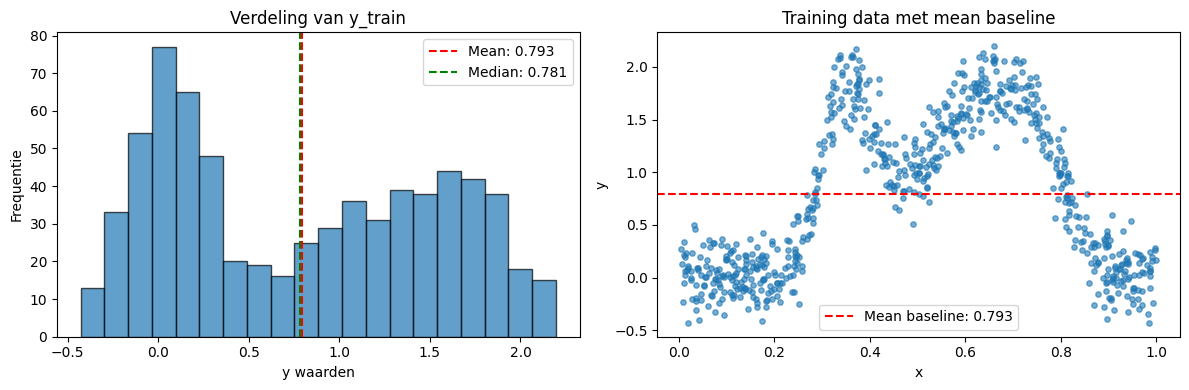

In [82]:
# Analyse van target variable voor null model keuze
print("Training data statistieken:")
print(f"y_train gemiddelde: {y_train.mean():.4f}")
print(f"y_train mediaan: {np.median(y_train):.4f}")
print(f"y_train standaarddeviatie: {y_train.std():.4f}")
print(f"y_train min: {y_train.min():.4f}")
print(f"y_train max: {y_train.max():.4f}")

# Visualiseer de verdeling
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean: {y_train.mean():.3f}')
plt.axvline(np.median(y_train), color='green', linestyle='--', label=f'Median: {np.median(y_train):.3f}')
plt.title('Verdeling van y_train')
plt.xlabel('y waarden')
plt.ylabel('Frequentie')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, alpha=0.6, s=15)
plt.axhline(y_train.mean(), color='red', linestyle='--', label=f'Mean baseline: {y_train.mean():.3f}')
plt.title('Training data met mean baseline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

### Null model

**Keuze voor mean baseline model:**

Op basis van de bovenstaande analyse van de target variabele gebruik ik het **gemiddelde van y_train (0.793)** als dummy regressor. Deze keuze is gebaseerd op:

**Wiskundig optimaal voor MSE:** Het gemiddelde minimaliseert de Mean Squared Error voor constante voorspellingen
**Consistentie met loss functie:** Omdat MSE ook de loss metric is van het neurale netwerk, zorgt dit voor een eerlijke vergelijking tijdens het trainen en valideren
**Symmetrische verdeling:** Mean (0.793) en mediaan (0.781) liggen dicht bij elkaar, wat een redelijk symmetrische verdeling aantoont

In [83]:
from sklearn.metrics import mean_squared_error

y_mean = np.mean(y_train)
print(f"Gemiddelde waarde van y_train: {y_mean:.4f}")

y_val_baseline = np.full_like(y_val, y_mean)

mse_baseline = mean_squared_error(y_val, y_val_baseline)
rmse_baseline = np.sqrt(mse_baseline)

print(f"Baseline MSE : {mse_baseline:.4f}")

Gemiddelde waarde van y_train: 0.7929
Baseline MSE : 0.5799


### Reusable evaluation function

In [84]:
def plot_training_history(history, iteration_name=""):
    if not hasattr(history, 'history') or not history.history:
        print("No training history available")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    title_prefix = f"{iteration_name} - " if iteration_name else ""
    
    # Loss plot with fixed scale
    if 'loss' in history.history:
        ax1.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title(f'{title_prefix}Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_ylim(0, 0.8)  # Fixed scale from 0 to 0.8 for comparability
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # MAE plot with fixed scale
    if 'mae' in history.history:
        ax2.plot(history.history['mae'], label='Training MAE')
    if 'val_mae' in history.history:
        ax2.plot(history.history['val_mae'], label='Validation MAE')
    ax2.set_title(f'{title_prefix}MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.set_ylim(0, 0.8)  # Fixed scale from 0 to 0.8 for comparability
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_model_predictions(model, X_test, y_test, xplot, yplot, iteration_name=""):
    xpred = xplot
    ypred = model.predict(xpred)
    title_prefix = f"{iteration_name} - " if iteration_name else ""
    
    plt.figure(figsize=(10, 6))
    plt.plot(X_test, y_test, 'ro', alpha=0.6, label='Test data', markersize=4)
    plt.plot(xpred, ypred, 'b-', label='Model voorspelling', linewidth=2)
    plt.title(f'{title_prefix}Model Voorspellingen vs Test Data')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def evaluate_model(model, history, X_train, y_train, X_test, y_test, xplot, yplot, f, iteration_name=""):
    print(f"\n=== {iteration_name if iteration_name else 'Model'} EVALUATION ===")
    
    # 1. Training history
    plot_training_history(history, iteration_name)
    
    # 2. Model predictions
    plot_model_predictions(model, X_test, y_test, xplot, yplot, iteration_name)
    
    # 3. Final metrics
    if hasattr(history, 'history') and history.history:
        if 'val_loss' in history.history and 'val_mae' in history.history:
            final_loss = history.history['val_loss'][-1]
            final_mae = history.history['val_mae'][-1]
            print(f"Final Validation Loss (MSE): {final_loss:.4f}")
            print(f"Final Validation MAE: {final_mae:.4f}")
    
    print(f"=== END {iteration_name if iteration_name else 'Model'} ===\n")

## Deel 3

Fit een zo simpel mogelijk model. Je zult hiervoor meerdere iteraties doorlopen, leg bij iedere iteratie uit
- welke keuzes je hebt gemaakt, en waarom?
- wat je opvalt aan het model en hoe je dit in een volgende iteratie aan gaat pakken.

Wees kort en bondig.

(Als je een 'dood spoor' in gaat, mag je deze iteraties wissen... we willen het proces zien hoe je bij je uiteindelijk model komt.)

> Jouw antwoord hier

### Iteratie 1 - Model architectuur zoals beschreven in deel 1

**Architectuur:**
- 1 verborgen laag met 4 neuronen
- tanh activatie functie
- Xavier weight initialisatie
- Geen bias in output laag want de data is ook zonder bias gegenereerd

- Voor de optimizer wil ik eerst Adam proberen, volgens [An overview of gradient descent optimization
algorithms](https://arxiv.org/pdf/1609.04747) op pagina 8 net boven de heading van 4.7 AdaMax wordt beschreven hoe Adam een goede basis is omdat het een veel gevallen beter werkt dan adaptive learning-methods zonder veel hyper parameter tweaking. 
- Voor de learnign loss kies ik MSE wat vaak gebruikt wordt voor regressie zodat het grotere fouten zwaarder mee rekent dan kleinere.
- Als performance metric gebruik ik MAE omdat het makkelijk interpreteerbaar is wat een van de eisen was voor deze opdracht.
- Voor de batch size begin ik met 32 wat een standaard waarde, en kijk ik later om dit aan te passen dit is een goed start punt zoals beschreven in [Determination of Optimal Batch Size of Deep Learning Models with Time Series Data](https://www.mdpi.com/2071-1050/16/14/5936) onder de heading "Literature Review" waar gezegd wordt "Masters and Luschi demonstrated that the advantages of small batch size were better generalization performance, better training stability, and the ability to choose a much larger range of learning rates. It was recommended to use small batches of 2 to 32 to build the models.".
- De epochs zet ik voor de eerste versie op 100 om mee te beginnen om een idee te krijgen van hoeveel er nodig is met trainen.
- De learning rate heb ik op de 0.001 standaard gelaten wat een goede middle middle ground is voor veel problemen en daarom de default value is.


In [85]:
model_v1 = keras.Sequential([
    keras.layers.Dense(4, 
                      activation='tanh', 
                      kernel_initializer='glorot_uniform',  # Xavier initialisatie
                      input_shape=(1,)),
    keras.layers.Dense(1, 
                      use_bias=False,  # Geen bias in output laag
                      kernel_initializer='glorot_uniform')
])

# Compile model met Adam optimizer en MSE loss
model_v1.compile(keras.optimizers.Adam(learning_rate=0.001), 
                loss='mean_squared_error',
                metrics=['mae'])


# Train het model
history_v1 = model_v1.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=100,              # More epochs
                         batch_size=32,
                         verbose=1,               # Progress bar per epoch
                         )

# Bewaar dit model als final_model voor de plot in deel 4
final_model = model_v1

print(f"\nModel samenvatting:")
model_v1.summary()

Epoch 1/100
16/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6843 - mae: 0.6765

C:\Users\Frank\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6491 - mae: 0.6584 - val_loss: 0.6622 - val_mae: 0.6670
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6128 - mae: 0.6445 - val_loss: 0.6279 - val_mae: 0.6537
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5812 - mae: 0.6334 - val_loss: 0.5975 - val_mae: 0.6417
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5545 - mae: 0.6234 - val_loss: 0.5734 - val_mae: 0.6312
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5335 - mae: 0.6153 - val_loss: 0.5542 - val_mae: 0.6214
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5180 - mae: 0.6095 - val_loss: 0.5397 - val_mae: 0.6136
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5074 - mae: 0.6052 - val_loss: 0.5300 - val_mae: 0.6079
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5000 - mae: 0.6018 - val_loss: 0.5241 - val_mae: 0.6047
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4963 - mae: 0.6

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26 (104.00 B)


=== Iteratie 1 EVALUATION ===


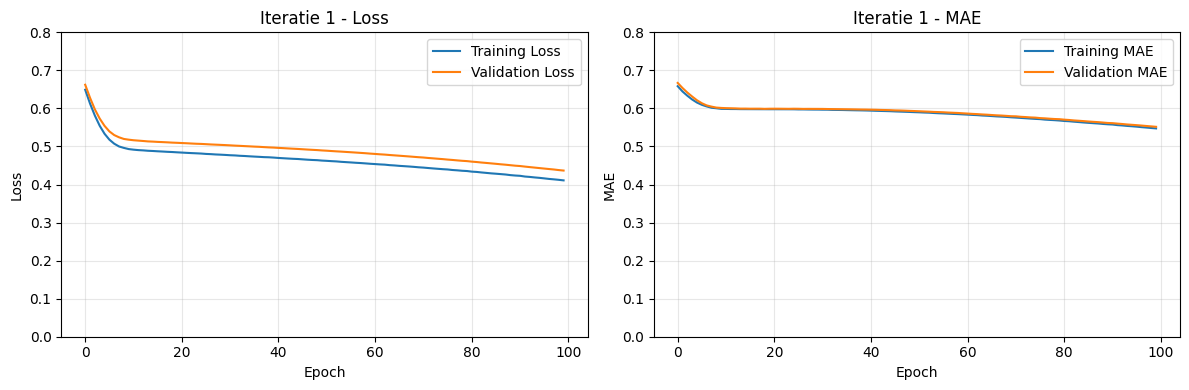

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


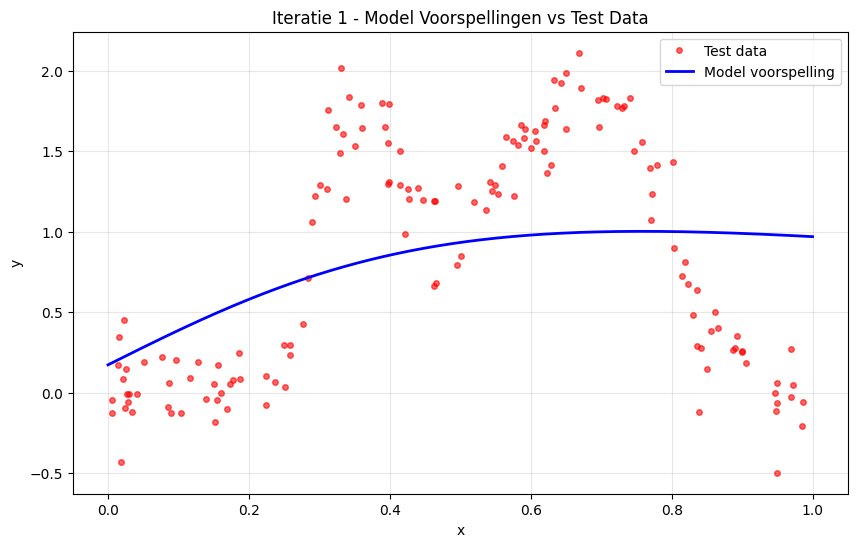

Final Validation Loss (MSE): 0.4367
Final Validation MAE: 0.5517
=== END Iteratie 1 ===



In [86]:
# Evaluation for Iteration 1
evaluate_model(model_v1, history_v1, X_train, y_train, X_test, y_test, xplot, yplot, f, "Iteratie 1")

**Resultaat**

Bij de eerste iteratie zie ik dat het epoch aantal veels te laag is en ik dit onderschat had omdat het probleem heel simpel is.

### Iteratie 2 extra training

**Wijzigingen**
Ik zie dat 100 epochs veels te weinig is en het trainen enorm snel gaat daarom zet ik de epochs nu op 1000 met early stoppping op basis van de `val_loss` en `restore_best_weights=True` om te zorgen dat er genoeg getrained wordt maar ook optijd gestopt.

In [87]:
model_v1 = keras.Sequential([
    keras.layers.Dense(4, 
                      activation='tanh', 
                      kernel_initializer='glorot_uniform',  # Xavier initialisatie
                      input_shape=(1,)),
    keras.layers.Dense(1, 
                      use_bias=False,  # Geen bias in output laag
                      kernel_initializer='glorot_uniform')
])

# Compile model met Adam optimizer en MSE loss
model_v1.compile(keras.optimizers.Adam(learning_rate=0.001), 
                loss='mean_squared_error',
                metrics=['mae'])

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=25,             # Stop after 10 epochs without improvement
    restore_best_weights=True # Restore weights from best epoch
)

# Train het model
history_v1 = model_v1.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=1000,              # More epochs
                         batch_size=32,
                         verbose=1,               # Progress bar per epoch
                         callbacks=[early_stopping])

# Bewaar dit model als final_model voor de plot in deel 4
final_model = model_v1

print(f"\nModel samenvatting:")
model_v1.summary()

Epoch 1/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5773 - mae: 0.6298 - val_loss: 0.5897 - val_mae: 0.6276
Epoch 2/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5544 - mae: 0.6178 - val_loss: 0.5707 - val_mae: 0.6171
Epoch 3/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5419 - mae: 0.6116 - val_loss: 0.5611 - val_mae: 0.6108
Epoch 4/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5354 - mae: 0.6090 - val_loss: 0.5559 - val_mae: 0.6075
Epoch 5/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5320 - mae: 0.6072 - val_loss: 0.5524 - val_mae: 0.6055
Epoch 6/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5298 - mae: 0.6065 - val_loss: 0.5498 - val_mae: 0.6041
Epoch 7/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5275 - mae: 0.6064 - val_loss: 0.5481 - val_mae: 0.6047
Epoch 8/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5258 - mae: 0.6067 - val_loss: 0.5465 - val_mae: 0.6050
Epoch 9/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26 (104.00 B)


=== Iteratie 2 EVALUATION ===


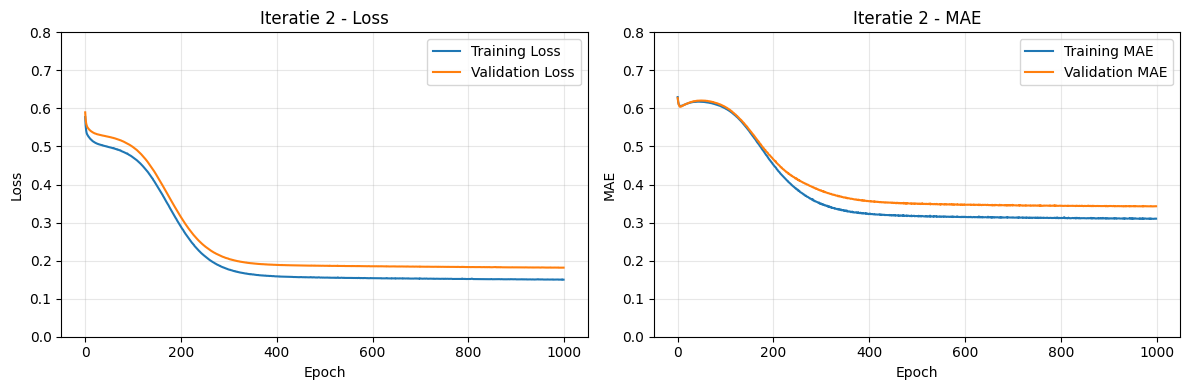

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


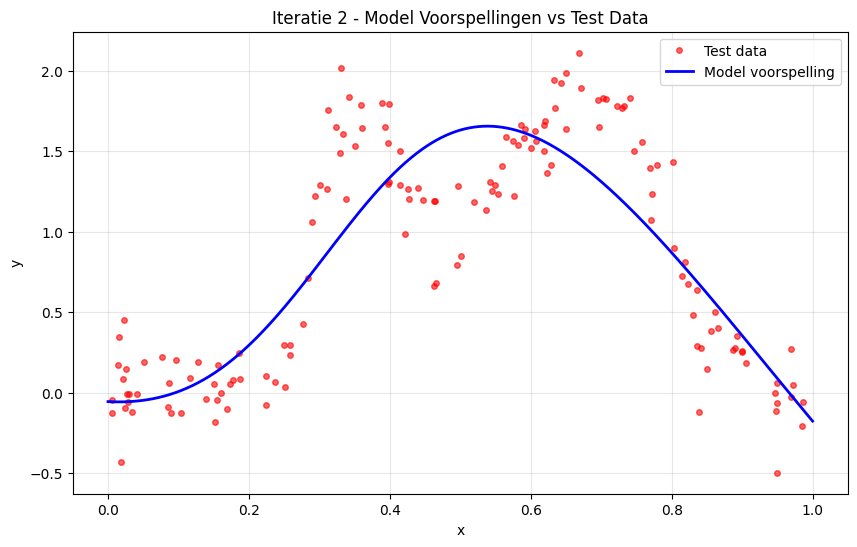

Final Validation Loss (MSE): 0.1816
Final Validation MAE: 0.3429
=== END Iteratie 2 ===



In [88]:
# Evaluation for Iteration 2
evaluate_model(model_v1, history_v1, X_train, y_train, X_test, y_test, xplot, yplot, f, "Iteratie 2")

**Resultaat**

Het resultaat is nu dat het model op ongeveer 500 epochs niks nieuws meer leert. Het blijft nog even een klein beetje op en neer springen en dan stopt het door de early stopping. De fout is nogsteeds hoog en de loss ook. Het lijkt er op dat het model in een lokaal minimum of plateau beland is waardoor het niet lukt verder te trainen en het overfit ook niet omdat het model niet complex genoeg is om de functie verder te fitten. 

### Iteratie 3

**Wijzigingen**

Omdat het leren vast lijkt te lopen met de standaard learning rate van 0.001 heb ik een oplossing nodig om het lokale minimum uit te komen. De eerste oplossing die ik ga proberen is het tweaken van de learning rate. Omdat dit het model even simpel houd en makkelijker uit te leggen houd als er veranderingen zijn. Ik ga de learning rate hoger maken zodat er meer exploration mogelijk is voor het model en meer kans om uit lokale minima te komen.

In [89]:
model_v1 = keras.Sequential([
    keras.layers.Dense(4, 
                      activation='tanh', 
                      kernel_initializer='glorot_uniform',  # Xavier initialisatie
                      input_shape=(1,)),
    keras.layers.Dense(1, 
                      use_bias=False,  # Geen bias in output laag
                      kernel_initializer='glorot_uniform')
])

# Compile model met Adam optimizer en MSE loss
model_v1.compile(keras.optimizers.Adam(learning_rate=0.1), 
                loss='mean_squared_error',
                metrics=['mae'])

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=25,             # Stop after 10 epochs without improvement
    restore_best_weights=True # Restore weights from best epoch
)

# Train het model
history_v1 = model_v1.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=1000,              # More epochs
                         batch_size=32,
                         verbose=1,               # Progress bar per epoch
                         callbacks=[early_stopping])

# Bewaar dit model als final_model voor de plot in deel 4
final_model = model_v1

print(f"\nModel samenvatting:")
model_v1.summary()

Epoch 1/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5130 - mae: 0.6225 - val_loss: 0.5165 - val_mae: 0.6064
Epoch 2/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4612 - mae: 0.5788 - val_loss: 0.4512 - val_mae: 0.5508
Epoch 3/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3768 - mae: 0.5084 - val_loss: 0.4512 - val_mae: 0.5621
Epoch 4/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3271 - mae: 0.4694 - val_loss: 0.2790 - val_mae: 0.4423
Epoch 5/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2458 - mae: 0.4092 - val_loss: 0.2298 - val_mae: 0.4140
Epoch 6/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1972 - mae: 0.3668 - val_loss: 0.2045 - val_mae: 0.3806
Epoch 7/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1793 - mae: 0.3455 - val_loss: 0.2025 - val_mae: 0.3683
Epoch 8/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1813 - mae: 0.3408 - val_loss: 0.2453 - val_mae: 0.4066
Epoch 9/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - lo

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26 (104.00 B)


=== Iteratie 3 EVALUATION ===


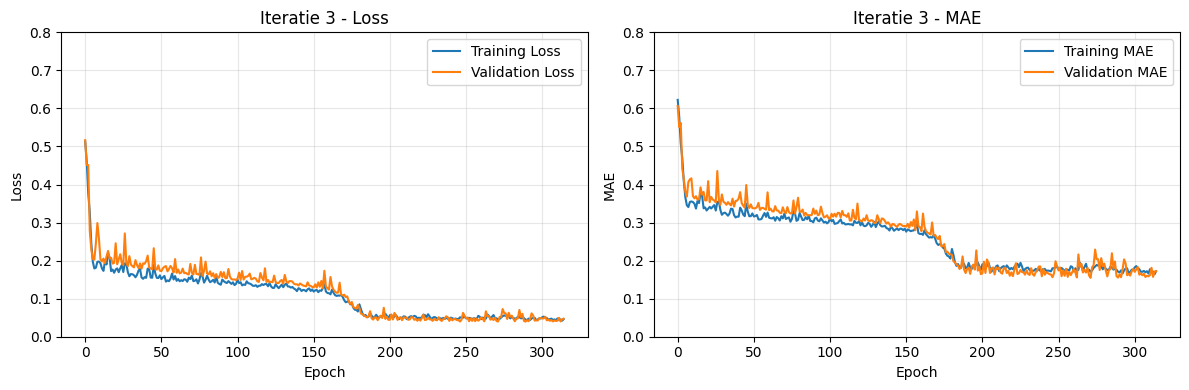

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


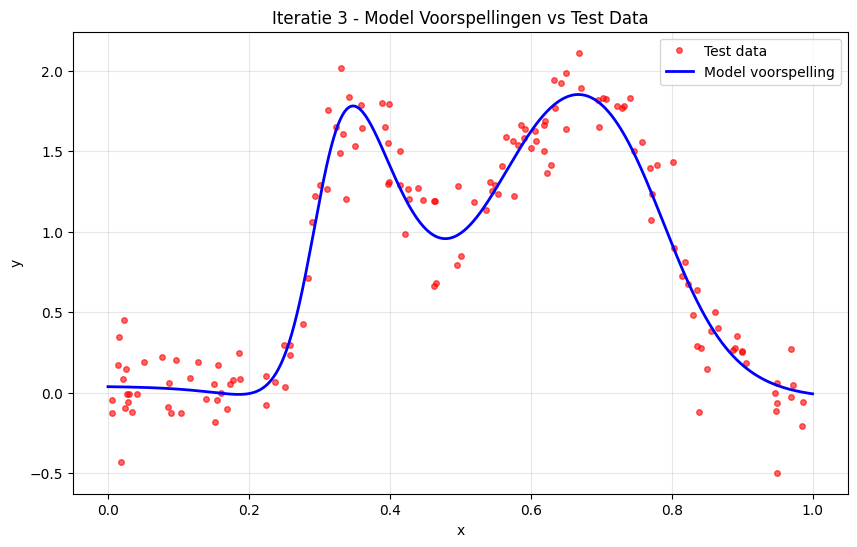

Final Validation Loss (MSE): 0.0474
Final Validation MAE: 0.1718
=== END Iteratie 3 ===



In [90]:
# Evaluation for Iteration 3
evaluate_model(model_v1, history_v1, X_train, y_train, X_test, y_test, xplot, yplot, f, "Iteratie 3")

### Iteratie 4

**Wijzigingen**

`learning rate 0.1`
Epoch 166/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0544 - mae: 0.1853 - val_loss: 0.0385 - val_mae: 0.1521

`learning rate 0.2`
Epoch 155/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0555 - mae: 0.1877 - val_loss: 0.0399 - val_mae: 0.1533

Ik heb de waardes 0.01, 0.001 en 0.1 geprobeert bij de eerste 2 pogingen was er niet veel verandering te zien ten opzichte van de default learning rate. Pas bij de learning rate van 0.1 en 0.2 wat hoge waardes zijn lukt het het model omd uit het lokale minimum te komen en meer te leren.

In [91]:
model_v1 = keras.Sequential([
    keras.layers.Dense(4, 
                      activation='tanh', 
                      kernel_initializer='glorot_uniform',  # Xavier initialisatie
                      input_shape=(1,)),
    keras.layers.Dense(1, 
                      use_bias=False,  # Geen bias in output laag
                      kernel_initializer='glorot_uniform')
])

# Compile model met Adam optimizer en MSE loss
model_v1.compile(keras.optimizers.Adam(learning_rate=0.2), 
                loss='mean_squared_error',
                metrics=['mae'])

# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=25,             # Stop after 10 epochs without improvement
    restore_best_weights=True # Restore weights from best epoch
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',     # what to watch
    factor=0.1,             # multiply LR by this factor
    patience=10,            # how many epochs of no improvement
    threshold=0.0001,
    min_lr=0,
    verbose=1
)

# Train het model
history_v1 = model_v1.fit(X_train, y_train, 
                         validation_data=(X_val, y_val),
                         epochs=1000,              # More epochs
                         batch_size=32,
                         verbose=1,               # Progress bar per epoch
                         callbacks=[early_stopping, reduce_lr])

# Bewaar dit model als final_model voor de plot in deel 4
final_model = model_v1

print(f"\nModel samenvatting:")
model_v1.summary()

Epoch 1/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6274 - mae: 0.6739 - val_loss: 0.5219 - val_mae: 0.6312 - learning_rate: 0.2000
Epoch 2/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4710 - mae: 0.5909 - val_loss: 0.5013 - val_mae: 0.5772 - learning_rate: 0.2000
Epoch 3/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4435 - mae: 0.5548 - val_loss: 0.4093 - val_mae: 0.5129 - learning_rate: 0.2000
Epoch 4/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3888 - mae: 0.5122 - val_loss: 0.3740 - val_mae: 0.5109 - learning_rate: 0.2000
Epoch 5/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2894 - mae: 0.4477 - val_loss: 0.2964 - val_mae: 0.4161 - learning_rate: 0.2000
Epoch 6/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2312 - mae: 0.3873 - val_loss: 0.2257 - val_mae: 0.3841 - learning_rate: 0.2000
Epoch 7/1000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1909 - mae: 0.3548 - val_loss: 0.2615 - val_mae: 0.4241 - learning_rate: 0.2000
Epoch 

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26 (104.00 B)


=== Iteratie 4 EVALUATION ===


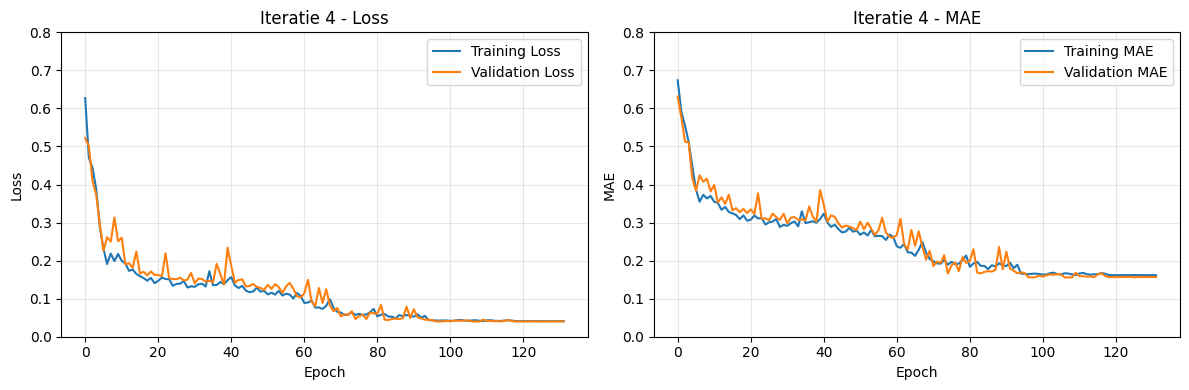

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


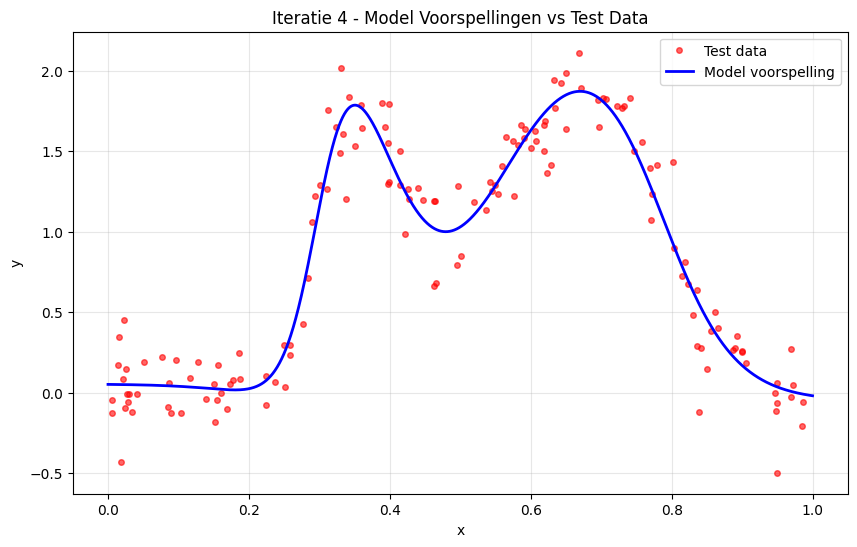

Final Validation Loss (MSE): 0.0402
Final Validation MAE: 0.1570
=== END Iteratie 4 ===



In [92]:
# Evaluation for Iteration 4
evaluate_model(model_v1, history_v1, X_train, y_train, X_test, y_test, xplot, yplot, f, "Iteratie 4")

## Final result

Nu met de laatste paar tweaks is de loss 0.04 en belangerijker de MAE is nu 0.1570. Omdat de gaussian noise op 0.2 stond wat al bekend is is de laagste mogelijke MAE die ook echt iets zegt 0.16. Door de random noise is het niet mogelijk om te zeggen of het model ook echt beter is daaronder omdat het gewoon zou kunnen fitten op de random noise. Daarom is dit mijn laatste model ook al fit het waarschijnlijk nogsteeds een tikkeltje op de noise is het beter dan mijn vorige versie.

## Deel 4

Onderstaande code plot de voorspellingskromme van jouw model $\hat{f}$, in het ideale geval ziet je resultaat er uit zoals hieronder, of beter, met blauwe en gestippelde lijnen vrijwel boven elkaar.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


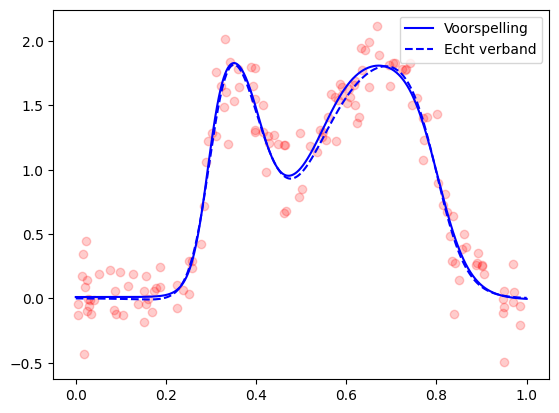

In [95]:
xpred = xplot
ypred = final_model.predict(xpred)

plt.plot(X_test, y_test, 'ro', alpha=0.2)
plt.plot(xpred, ypred, 'b-', label = 'Voorspelling')
plt.plot(xplot, yplot, 'b--', label = 'Echt verband')
plt.legend()
plt.show()

Voer deze code uit, wat valt je op? Zou je zeggen dat je de oorspronkelijke $f$ achterhaald hebt?

> Jouw antwoord hier

Wat op valt is dat het model bijna perfect fit op op het echte verband. In de 2de kromming is de lijn niet helemaal perfect maar dit is logisch vanwegen de noise. Het feit dat het model zo goed fit op het echt verband is ook deels te verklaren door de randomness en puur toeval. Omdat het vrijwel onmogelijk perfect gefit kan worden door de 0.2 gaussian noise en het laatste stuk van het fitten daarom puur toeval is omdat het model niet zou kunnen weten wat de realiteit is.

Omdat er veel randomness in het model is vanwegen de initalisatie van de weights, de split van de data, de batch size en ook de willekeur van hoe de training stappen verlopen heb ik daarom ook nog even vergeleken hoe het er uit zien met andere random seeds. Dit om te kijken of het model echt robust is of dat het puur toeval is dat het de juiste weights vond. Wat in dit geval minder waarschijnlijk is met oog op de iteraties maar toch mogelijk omdat het probleem simpel is. Door dit te bekijken werd het ook duidelijker dat het per toeval bijna perfect fit omdat op andere randomseeds de ongeveer de zelfde hoeveelheid noise mee genomen is maar op net iets andere plekken.

## Deel 5

Bestudeer de gewichten van je model, zou je zeggen dat je de oorspronkelijke $f$ achterhaald hebt?

In [106]:
# retrieve de weights en biases
weights = final_model.get_weights()

# Verborgen laag (layer 1) de inpot naar 4 neuronen
hidden_weights = weights[0]  # Shape: (1, 4) - van 1 input naar 4 neuronen  
hidden_biases = weights[1]   # Shape: (4,) - bias van de neuronen

# Output laag (layer 2): van 4 neuronen naar de 1 output (geen bias)
output_weights = weights[2]  # Shape: (4, 1)

print("VERBORGEN LAAG WEIGHTS (input -> 4 neuronen):")
print(f"Shape: {hidden_weights.shape}")
for i in range(4):
    print(f"  Neuron {i+1}: weight = {hidden_weights[0,i]:.4f}, bias = {hidden_biases[i]:.4f}")

print(f"\nOUTPUT LAAG WEIGHTS (4 neuronen -> output):")
print(f"Shape: {output_weights.shape}")
for i in range(4):
    print(f"  van Neuron {i+1}: weight = {output_weights[i,0]:.4f}")

print(f"\nTOTAAL AANTAL PARAMETERS: {final_model.count_params()}")

VERBORGEN LAAG WEIGHTS (input -> 4 neuronen):
Shape: (1, 4)
  Neuron 1: weight = 25.9071, bias = -7.6039
  Neuron 2: weight = -14.2925, bias = 11.4747
  Neuron 3: weight = 12.3337, bias = -6.7307
  Neuron 4: weight = -19.2273, bias = 7.8025

OUTPUT LAAG WEIGHTS (4 neuronen -> output):
Shape: (4, 1)
  van Neuron 1: weight = 1.0293
  van Neuron 2: weight = 0.9582
  van Neuron 3: weight = 0.6121
  van Neuron 4: weight = 0.6938

TOTAAL AANTAL PARAMETERS: 12


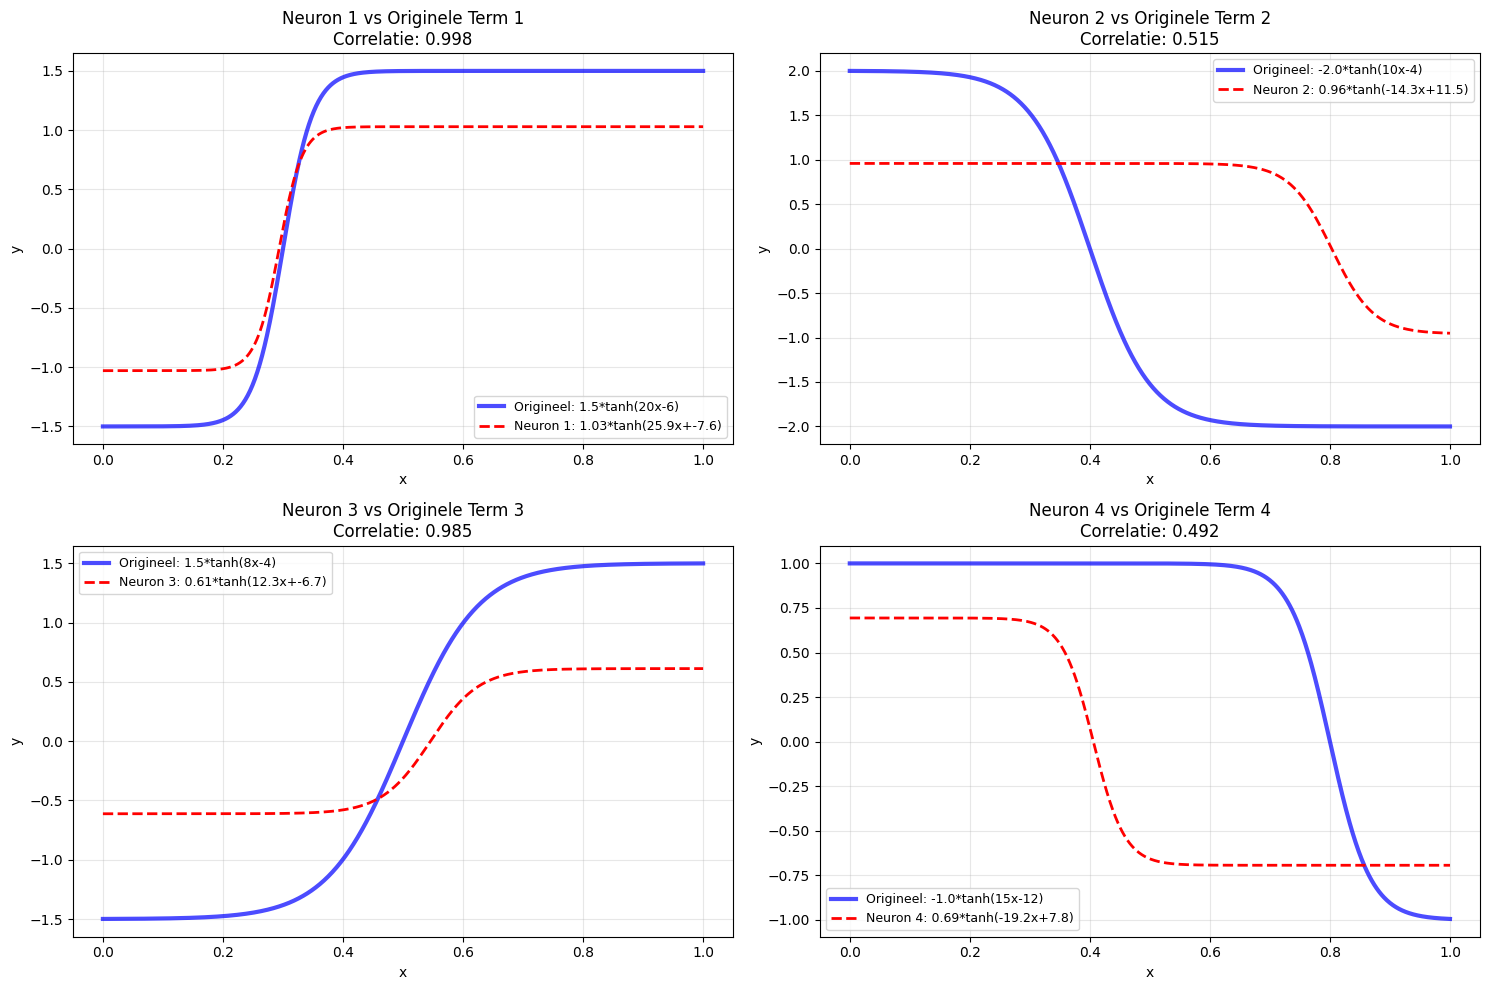

In [107]:
# Versimpelde analyse: Directe vergelijking per neuron vs originele tanh-functie
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

x_detailed = np.linspace(0, 1, 1000)

# Originele tanh functies
original_funcs = [
    (1.5, 20, -6, '1.5*tanh(20x-6)'),     # Term 1
    (-2.0, 10, -4, '-2.0*tanh(10x-4)'),   # Term 2  
    (1.5, 8, -4, '1.5*tanh(8x-4)'),       # Term 3
    (-1.0, 15, -12, '-1.0*tanh(15x-12)')  # Term 4
]

# Plot elke neuron vs corresponderende originele functie
for i in range(4):
    # Originele functie
    orig_coeff, orig_scale, orig_shift, orig_label = original_funcs[i]
    orig_func = orig_coeff * np.tanh(orig_scale * x_detailed + orig_shift)
    
    # Geleerde neuron
    learned_coeff = output_weights[i,0]
    learned_scale = hidden_weights[0,i] 
    learned_shift = hidden_biases[i]
    learned_func = learned_coeff * np.tanh(learned_scale * x_detailed + learned_shift)
    
    # Plot vergelijking
    axes[i].plot(x_detailed, orig_func, 'b-', linewidth=3, 
                 label=f'Origineel: {orig_label}', alpha=0.7)
    axes[i].plot(x_detailed, learned_func, 'r--', linewidth=2, 
                 label=f'Neuron {i+1}: {learned_coeff:.2f}*tanh({learned_scale:.1f}x+{learned_shift:.1f})')
    
    # Bereken similarity score (correlatie)
    correlation = np.corrcoef(orig_func, learned_func)[0,1]
    
    axes[i].set_title(f'Neuron {i+1} vs Originele Term {i+1}\nCorrelatie: {correlation:.3f}')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

plt.tight_layout()
plt.show()

Bij het vergelijken van het echt verband en de functie lijkt het als of de functie achterhaalt is. Maar wanneer de weights geinspecteerd worden is het te zien dat dit niet het geval is. Vooral bij het kijken van de visualisatie is dit duidelijk. De neuronen kunnen net als de verschillende onderdelen van een functie verschillende volgordes hebben en toch de zelfde resultaat opleveren. Het is dus duidelijk te zien dat het model een alternatieve parameter representatie geleerd heeft, maar dat die wel kan leiden tot de zelfde voorspelling.

In conclusie, het model heeft de functie wel geleerd op functioneel niveau. Maar niet op parameter niveau.

## Deel 6

Evalueer je model met een geschikte kwaliteitsmaat. Wat valt je op?

In [110]:
# Evaluatie van het finale model met MAE als kwaliteitsmaat
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Test set voorspellingen
y_test_pred = final_model.predict(X_test, verbose=0)

# MAE scores
test_mae_model = mean_absolute_error(y_test, y_test_pred)
test_mae_baseline = mean_absolute_error(y_test, np.full_like(y_test, y_mean))

print("=== MODEL EVALUATIE ===")
print(f"Test MAE Model:     {test_mae_model:.4f}")
print(f"Test MAE Baseline:  {test_mae_baseline:.4f}")
print(f"Verbetering:        {((test_mae_baseline - test_mae_model) / test_mae_baseline * 100):.1f}%")

print(f"\nBaseline model (gemiddelde y_train): {y_mean:.4f}")
print(f"Theoretische ondergrens (noise σ):   {0.2:.4f}")

=== MODEL EVALUATIE ===
Test MAE Model:     0.1431
Test MAE Baseline:  0.6726
Verbetering:        78.7%

Baseline model (gemiddelde y_train): 0.7929
Theoretische ondergrens (noise σ):   0.2000


**Keuze voor MAE als kwaliteitsmaat:**
MAE is gekozen omdat het goed interpreteerbaar is het geeft de gemiddelde absolute afwijking in dezelfde eenheid als de target variabele. Dit past bij de eis van interpreteerbaarheid uit de functionele requirements en dit is goed interpreteer baar omdat voor het probleem sommige fouten niet meer wegen dan anderen.

**Resultaten:**
- **Model MAE**: 0.1431 
- **Baseline MAE**: 0.6726 (constant voorspelling met gemiddelde y_train = 0.7929)

**Conclusie:**
Het model presteert aanzienlijk beter dan verwacht. Met een MAE van 0.14 komt het dicht bij de theoretische ondergrens van 0.20 en de gewenste waarde van 0.16 die besproken was in de requirements. (de toegevoegde Gaussische ruis). Dit suggereert dat het model de onderliggende functie f(x) bijna perfect heeft geleerd, ondanks dat de parameter-representatie verschilt van de originele functie. Het goede resultaat is deels toe te schrijven aan de randomness zoals eerder beschreven, maar toont aan dat het simpele 4-neuron model voldoende capaciteit heeft voor dit probleem zoals ook verwacht was aan de hand van de literatuur die ik gevonden had. Ook verslaat het model het nul model met gemak wat een van de requirements was. En is het duidelijk intrepreteerbaar gebleven zoals te zien in de vergelijking van de tanh functies en de geleerde parameters.